## Tutorial 5: Impact of ignoring the panel structure

**In this tutorial we look at the impact of ignoring the panel structure when in the true Data Generating Process the panel structure is present.**<br><br>
For this tutorial we use the same type of data as in tutorial 1, i.e. data from a two-alternative stated route choice experiment. 
But we will create more tasks per individual: 10 responses per decision maker as oppossed to 5, and more individuals (*N* = 400). Both changes will make the impact of accounting or ignoring the panel structure more pronounced.
<br>
<br>
<img src="assets/route_choice.png" alt="Route choice" width="400">

In [1]:
# Import the libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import biogeme.biogeme_logging as blog
import biogeme.database as db
import biogeme.biogeme as bio
from biogeme import models
from biogeme.expressions import Beta, Variable, bioDraws, log, MonteCarlo, exp, bioMultSum, exp

# Set the number of columns to display in pandas
pd.set_option('display.max_columns', None)

In [2]:
# Add the utils folder to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import the bio_estimation_fcns from the utils folder
from utils.bio_estimation_fcns import print_results, estimate_mnl, estimate_panel_mxl

#### Biogeme optimiser and logging settings
The file biogeme.toml contains the settings for the optimiser. In this file, we set the number of draws for estimating Mixed Logit models to 250. We use a relatively low number to avoid long estimation times.
Also, we invoke a so-called logger which enables us to see the progress during estimation.

In [3]:
# Initialize the logger, if it has not been initialized yet
try:
    logger
except NameError:    
    logger = blog.get_screen_logger(level=blog.INFO)
    print('Logger has been initialised')

Logger has been initialised


### 1. Create the synthetic Panel RUM-ML data

In [4]:
# Create np array with the choice tasks (TC1, TT1, TC2, TT2). 
# Each row is a choice task, and each column is an attribute of the choice task.
# This design is obtained using Ngene software.
tasks = np.array([  [5, 25, 7, 35],
                    [8, 20, 5, 40],
                    [6, 20, 6, 40],
                    [7, 35, 5, 25],
                    [6, 40, 6, 25],
                    [8, 25, 4, 35],
                    [4, 30, 8, 30],
                    [4, 35, 8, 20],
                    [5, 40, 7, 20],
                    [7, 30, 4, 30]])

# Determine the number of choice situations per respondent
T = len(tasks)

# Set the number of respondents
N = 400

# Replicate the tasks N times
data = np.tile(tasks, (N, 1))

# Create respondent IDs to add to the dataframe
resp_id = np.expand_dims(np.repeat(np.arange(1, N+1), T), axis=1)

# Create a pandas dataframe
df = pd.DataFrame(np.concatenate((resp_id,data), axis=1), columns=['RESP','TC1', 'TT1', 'TC2', 'TT2'])

# Show the first 15 rows of the dataframe
df.head(15)

,RESP,TC1,TT1,TC2,TT2
0,1,5,25,7,35
1,1,8,20,5,40
2,1,6,20,6,40
3,1,7,35,5,25
4,1,6,40,6,25
5,1,8,25,4,35
6,1,4,30,8,30
7,1,4,35,8,20
8,1,5,40,7,20
9,1,7,30,4,30


#### True DGP
Let's create (synthetic) choices with a linear-additive Panel RUM-ML. To do so, we assume:
1. All decision makers (denoted *n*) maximise utility (decision rule)
2. Travel cost, travel time and the label matter to the choice behaviour
3. Travel cost and travel time are normally distributed across individuals in the population:<br>
$\beta_{tc_n} = \mathcal{N}(\mu_{tc},\sigma_{tc})$ <br>
$\beta_{tt_n} = \mathcal{N}(\mu_{tt},\sigma_{tt})$ <br>
$ASC_1 = 0$   $\forall \textit{n}$ <br>
$ASC_2 = 0.5$ $\forall \textit{n}$ <br>
where: 
$ASC_2 = 0.5$, $\mu_{tc} = -0.6$, $\mu_{tt} = -0.15$, $\sigma_{tc} = 0.15$, and $\sigma_{tc} = 0.04$<br>
4. Unobserved utilities are i.i.d. EV type I distributed<br>

Hence, the utility function with this linear-additive Panel RUM-ML DGP is:<br><br>
$U_{in} = V_{in} + \varepsilon_{in}$<br>

$U_{in} = ASC_{i} + \beta_{tc_n} \cdot x^{tc}_{in} + \beta_{tt_n} \cdot x^{tt}_{in} + \varepsilon_{in}$<br>

In [5]:
# Define the true utility parameters
asc_1 = 0
asc_2 = 0.5
mu_tc = -0.6
mu_tt = -0.15
sigma_tc = 0.15
sigma_tt = 0.04

print('True decision rule: Random Utility Maximisation (RUM), with parameters:')
print(f'   asc1 = {asc_1} for all decision makers')
print(f'   asc2 = {asc_2} for all decision makers')
print(f'   beta_TC is normally distributed across decision makers with location: {mu_tc:0.2f} and standard deviation: {sigma_tc:0.2f}')
print(f'   beta_TT is normally distributed across decision makers with location: {mu_tt:0.2f} and standard deviation: {sigma_tt:0.2f}')

True decision rule: Random Utility Maximisation (RUM), with parameters:
   asc1 = 0 for all decision makers
   asc2 = 0.5 for all decision makers
   beta_TC is normally distributed across decision makers with location: -0.60 and standard deviation: 0.15
   beta_TT is normally distributed across decision makers with location: -0.15 and standard deviation: 0.04


#### Create the true taste parameters

In [6]:
# Fix the seed to make the results replicable
np.random.seed(42)

# Draw values beta_TC and beta_TT for each decision maker
beta_tcn = np.random.normal(mu_tc, sigma_tc, N)
beta_ttn = np.random.normal(mu_tt, sigma_tt, N)

# Replicate the values of beta_TC and beta_TT for each choice situation
beta_tc = np.repeat(beta_tcn,T)
beta_tt = np.repeat(beta_ttn,T)

# Show the panel structure
true_betas = pd.DataFrame({'RESP':df['RESP'],'B_tc_n': beta_tc, 'B_tt_n': beta_tt})
true_betas.head(15)

,RESP,B_tc_n,B_tt_n
0,1,-0.525493,-0.213777
1,1,-0.525493,-0.213777
2,1,-0.525493,-0.213777
3,1,-0.525493,-0.213777
4,1,-0.525493,-0.213777
5,1,-0.525493,-0.213777
6,1,-0.525493,-0.213777
7,1,-0.525493,-0.213777
8,1,-0.525493,-0.213777
9,1,-0.525493,-0.213777


`--> Note that we assume an individual has stable taste parameters across choice tasks.`

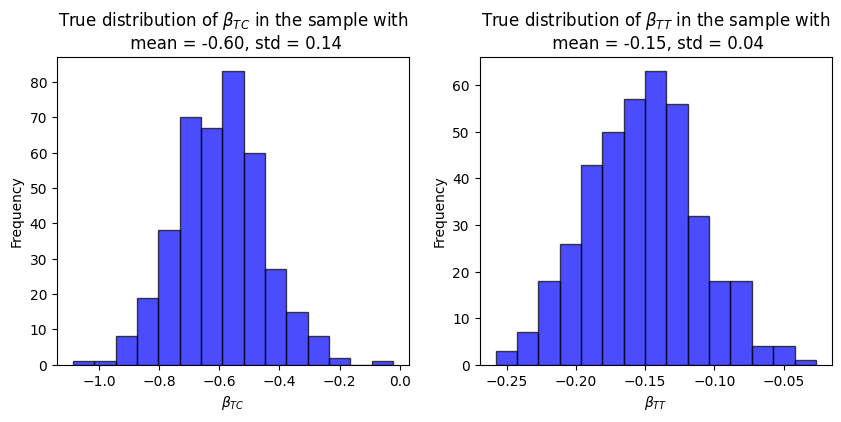

In [7]:
# Verify the distribution of beta_tc and beta_tt using a plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(beta_tcn, bins=15, color='blue', alpha=0.7, edgecolor='black')
ax[0].set_title(f'True distribution of $\\beta_{{TC}}$ in the sample with\n mean = {np.mean(beta_tcn):.2f}, std = {np.std(beta_tcn):.2f}')
ax[1].hist(beta_ttn, bins=15, color='blue', alpha=0.7, edgecolor='black')
ax[1].set_title(f'True distribution of $\\beta_{{TT}}$ in the sample with\n mean = {np.mean(beta_ttn):.2f}, std = {np.std(beta_ttn):.2f}')

ax[0].set_xlabel('$\\beta_{TC}$')
ax[1].set_xlabel('$\\beta_{TT}$')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
plt.show()

#### Compute the choices using the true DGP

In [8]:
# Compute the utilities given the DGP
df['V1'] = asc_1 + beta_tc * df['TC1'] + beta_tt * df['TT1'] 
df['V2'] = asc_2 + beta_tc * df['TC2'] + beta_tt * df['TT2']

# Add the error terms
df['epsilon1'] = np.random.gumbel(size=len(df))
df['epsilon2'] = np.random.gumbel(size=len(df))

# Compute the total utility
df['U1'] = df['V1'] + df['epsilon1']
df['U2'] = df['V2'] + df['epsilon2']

# Identify the chosen alternative
df['CHOICE'] = np.nan
df.loc[df['U1'] > df['U2'], 'CHOICE'] = 1
df.loc[df['U2'] > df['U1'], 'CHOICE'] = 2

# Convert the chosen alternative to an integer (optional)
df['CHOICE'] = df['CHOICE'].astype(int)

# Save the data in a csv file
data_path =  Path(f'data/synthetic_VTTdata_tutorial3.dat')
df[['RESP','TC1', 'TT1', 'TC2', 'TT2','CHOICE']].to_csv(data_path, sep=',', index=False)

# Show the first rows
df.head()
# df.value_counts('CHOICE')

,RESP,TC1,TT1,TC2,TT2,V1,V2,epsilon1,epsilon2,U1,U2,CHOICE
0,1,5,25,7,35,-7.971892,-10.660649,0.956226,-0.258462,-7.015666,-10.919111,1
1,1,8,20,5,40,-8.479485,-10.678549,-0.568489,2.045503,-9.047974,-8.633046,2
2,1,6,20,6,40,-7.428499,-11.204042,3.277835,1.019855,-4.150664,-10.184187,1
3,1,7,35,5,25,-11.160649,-7.471892,0.097603,0.274050,-11.063046,-7.197842,2
4,1,6,40,6,25,-11.704042,-7.997385,1.341794,0.185042,-10.362247,-7.812342,2


`--> We have created a data set in which the DGP is linear-additive Panel RUM-ML`<br>

### 2. Recovery of the model parameters
Now, let's have a look what happens if we estimate a discrete choice model that **perfectly** aligns with the DGP. When we do so, we expect we are able to accurately recover the true parameters.

#### Create a biogeme database in wide format

In [9]:
# Define the Biogeme database object
biodata = db.Database('synthetic_VTTdata_tutorial3', df[['RESP','TC1', 'TT1', 'TC2', 'TT2','CHOICE']].copy())

# Tell Biogeme which variable is the identifier of the individuals
biodata.panel('RESP')

# Calculate the number of observations per individual
obs_per_ind = biodata.data['RESP'].value_counts().unique()[0]
print(f'Number of observations per individual: {obs_per_ind}')

# Use biogeme's "generateFlatPanelDataFrame to create a wide database in which each row corresponds to one individual
df_wide = biodata.generate_flat_panel_dataframe(identical_columns=None)

# Rename the columns, such that they run from columnname_{0} to columnname_{n} 
renumbered_columns = {col: f'{col.split("_")[1]}_{int(col.split("_")[0])-1}' if len(col.split("_")) == 2 else col for col in df_wide.columns}

# Rename the columns using the dictionary
df_wide.rename(columns=renumbered_columns, inplace=True)

# Create Biogeme database object
biodata_wide = db.Database('synthetic_VTTdata_tutorial3_wide', df_wide)
biodata_wide.data.head()

Number of observations per individual: 10


,CHOICE_0,TC1_0,TC2_0,TT1_0,TT2_0,CHOICE_1,TC1_1,TC2_1,TT1_1,TT2_1,CHOICE_2,TC1_2,TC2_2,TT1_2,TT2_2,CHOICE_3,TC1_3,TC2_3,TT1_3,TT2_3,CHOICE_4,TC1_4,TC2_4,TT1_4,TT2_4,CHOICE_5,TC1_5,TC2_5,TT1_5,TT2_5,CHOICE_6,TC1_6,TC2_6,TT1_6,TT2_6,CHOICE_7,TC1_7,TC2_7,TT1_7,TT2_7,CHOICE_8,TC1_8,TC2_8,TT1_8,TT2_8,CHOICE_9,TC1_9,TC2_9,TT1_9,TT2_9
RESP,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,5,7,25,35,2,8,5,20,40,1,6,6,20,40,2,7,5,35,25,2,6,6,40,25,1,8,4,25,35,1,4,8,30,30,2,4,8,35,20,2,5,7,40,20,2,7,4,30,30
2,1,7,4,30,30,2,5,7,40,20,1,4,8,30,30,2,8,4,25,35,2,4,8,35,20,2,7,5,35,25,1,6,6,20,40,1,8,5,20,40,1,5,7,25,35,2,6,6,40,25
3,2,7,4,30,30,2,5,7,40,20,1,4,8,35,20,2,4,8,30,30,2,8,4,25,35,2,6,6,40,25,1,6,6,20,40,1,8,5,20,40,1,5,7,25,35,2,7,5,35,25
4,1,4,8,30,30,2,7,4,30,30,2,5,7,40,20,2,4,8,35,20,2,8,4,25,35,1,6,6,20,40,2,7,5,35,25,2,6,6,40,25,1,8,5,20,40,1,5,7,25,35
5,2,7,4,30,30,2,5,7,40,20,2,4,8,35,20,1,4,8,30,30,1,8,4,25,35,2,7,5,35,25,1,6,6,20,40,2,8,5,20,40,1,5,7,25,35,2,6,6,40,25


In [10]:
# Make dictionaries with the Biogeme variables from the wide database
TC1   =   {q: Variable(f'TC1_{q}') for q in range(obs_per_ind)}
TT1   =   {q: Variable(f'TT1_{q}') for q in range(obs_per_ind)}
TC2   =   {q: Variable(f'TC2_{q}') for q in range(obs_per_ind)}
TT2   =   {q: Variable(f'TT2_{q}') for q in range(obs_per_ind)}
CHOICE  = {q: Variable(f'CHOICE_{q}') for q in range(obs_per_ind)}

#### Estimate the discrete choice model that does capture the panel structure
The true DGP is a linear-additive Panel RUM-ML. Therefore, we first estimate this model.<br>
Note that estimating this model may take a couple of minutes.

We define the model specification.

In [11]:
# Give the model a name
model_name = 'Panel RUM-ML model with normally distributed parameters'

# Parameters definition enabling the construction of random parameters
ASC1       = Beta('ASC1',         0, None, None, 1)
ASC2       = Beta('ASC2',         0, None, None, 0)
mu_tc      = Beta('mu_tc',     -0.1, None, None, 0)    
mu_tt      = Beta('mu_tt',     -0.1, None, None, 0)    
sigma_tc   = Beta('sigma_tc ',  0.1, None, None, 0)
sigma_tt   = Beta('sigma_tt ',  0.1, None, None, 0)

# Construction of random parameters   
B_tc_rnd = mu_tc   + sigma_tc   * bioDraws('B_tc_rnd', 'NORMAL_HALTON2')
B_tt_rnd = mu_tt   + sigma_tt   * bioDraws('B_tt_rnd', 'NORMAL_HALTON2')

# Definition of the utility functions
# Note that we use list comprehension to create a list of utility functions for all observations of an individual 
V1 = [(ASC1 + B_tc_rnd * TC1[q] + B_tt_rnd * TT1[q]) for q in range(obs_per_ind)]
V2 = [(ASC2 + B_tc_rnd * TC2[q] + B_tt_rnd * TT2[q]) for q in range(obs_per_ind)]

# Create a dictionary to list the utility functions with the numbering of alternatives
# Note that we use list comprehension to create a list of dictionaries
V = [{1: V1[q], 2: V2[q]} for q in range(obs_per_ind)]
           
# Create a dictionary to describe the availability conditions of each alternative
AV = {1:1, 2:1}

In [12]:
# Estimate the model using the estimate_panel_mxl function
results_MXL = estimate_panel_mxl(V,AV,CHOICE,obs_per_ind,biodata_wide,model_name,num_draws = 100)

# Print the results
print_results(results_MXL)

Biogeme parameters read from biogeme.toml. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
The number of draws (100) is low. The results may not be meaningful. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: BFGS with trust region for simple bounds 
Iter.            ASC2           mu_tc           mu_tt       sigma_tc        sigma_tt      Function    Relgrad   Radius      Rho      
    0               0            -0.1            -0.1             0.1             0.1      2.1e+03       0.96      0.5     -0.3    - 
    1               0            -0.1            -0.1             


Estimation finished
Cause of termination           : Relative gradient = 0.0001 <= 0.00012
Number of iterations           :           78
Estimation time                :      0:00:39
Number of estimated parameters :            5
Number of individuals          :          400
Excluded observations          :            0
Null log likelihood            :     -2772.59
Init log likelihood            :     -2129.09
Final log likelihood           :     -1589.60
Rho-square for the null model  :        0.427
Bayesian Information Criterion :      3209.16
Number of threads              :           10
Number of draws                :          100
Types of draws                 : ['B_tc_rnd: NORMAL_HALTON2', 'B_tt_rnd: NORMAL_HALTON2']

            Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC2       0.5413        0.0453        11.96          0.00
mu_tc     -0.5629        0.0202       -27.93          0.00
mu_tt     -0.1518        0.0053       -28.46          0.00
sigma_tc   0.0733        0.03

`Based on the above estimation results, we can make a couple of observations:`<br><br>
`1. The true parameters are recovered well. The estimated parameters are close to the true values, i.e. within est ± 1.96 * S.E.`<br><br>
`2. The standard errors are fairly small, which is expected given the sample size.`<br><br>
`3. The model seems properly converged, as we see a good cause of termination, a decent rho square and no suspiciously large S.E. or parameter estimates.`


### 3. The effect of ignoring the panel structure
Now we are going to estimate a linear-additive RUM-MNL model. The utility function of this model is well specified (i.e. it matches the true DGP). But the MNL model does not account for panel structures (or the heterogeneity). That is, it cannot see that *N* individuals made *T* choices. Instead, it treats every observation as a new independent data point. Hence, it ignores the fact that individuals tastes are correlated across choice observations.

#### Estimate a linear-additive RUM-MNL model (i.e. a model that does not capture the panel structure)

In [13]:
# Give the model a name
model_name = 'MNL model'

# Define the Biogeme database object
biodata = db.Database('synthetic_VTTdata_tutorial4', df[['RESP','TC1', 'TT1', 'TC2', 'TT2','CHOICE']])

# We create Variable objects for each of the variables in the data set that we want to use in the model
TT1  = Variable('TT1')
TC1  = Variable('TC1')
TT2  = Variable('TT2')
TC2  = Variable('TC2')
CHOICE = Variable('CHOICE')

# Define the parameters to be estimated
ASC1 = Beta('ASC1', 0, None, None, 1)
ASC2 = Beta('ASC2', 0, None, None, 0)
B_TT = Beta('B_TT', 0, None, None, 0)
B_TC = Beta('B_TC', 0, None, None, 0)

# Define the utility functions
V1 = ASC1 + B_TT * TT1 + B_TC * TC1
V2 = ASC2 + B_TT * TT2 + B_TC * TC2

# Create a dictionary to list the utility functions with the numbering of alternatives
V = {1: V1, 2: V2}
    
# Create a dictionary called av to describe the availability conditions of each alternative, where 1 indicates that the alternative is available, and 0 indicates that the alternative is not available.
AV = {1: 1, 2: 1} 

# Estimate the model using the estimate_mnl function
results_MNL = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_MNL)

Biogeme parameters read from biogeme.toml. 
As the model is not too complex, we activate the calculation of second derivatives. If you want to change it, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
As the model is not too complex, we activate the calculation of second derivatives. If you want to change it, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: Newton with trust region for simple bounds 
Iter.            ASC2            B_TC            B_TT     Function    Relgrad   Radius      Rho      
    0            0.31           -0.39            -0.1      1.7e+03       0.87       10      1.1   ++ 
    1            0.46           -0.51           -0.13      1.6e+03       0.14    1e+02      1.1   ++ 
    2             0.5           -0.54           -0.14      1.6e+03     0.0064    1e+03        1   ++ 
    3         


Estimation finished
Cause of termination           : Relative gradient = 1.6e-05 <= 0.00012
Number of iterations           :            4
Estimation time                :      0:00:00
Number of estimated parameters :            3
Sample size                    :         4000
Excluded observations          :            0
Null log likelihood            :     -2772.59
Init log likelihood            :     -2772.59
Final log likelihood           :     -1609.39
Rho-square for the null model  :        0.420
Bayesian Information Criterion :      3243.66
Number of threads              :           10

       Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC2  0.5026        0.0459        10.96           0.0
B_TC -0.5433        0.0182       -29.90           0.0
B_TT -0.1416        0.0040       -35.11           0.0


In [14]:
# Compute the ratio of the standard errors for comparison
beta_hat_MXL = results_MXL.get_estimated_parameters()
beta_hat_MNL = results_MNL.get_estimated_parameters()
ratio_SE = beta_hat_MXL['Rob. Std err'][0:3].values/beta_hat_MNL['Rob. Std err'].values

# Show in a dataframe
pd.DataFrame(ratio_SE, columns=['Ratio of standard errors'], index=beta_hat_MNL.index)

,Ratio of standard errors
ASC2,0.986787
B_TC,1.109243
B_TT,1.322385


`--> We can make a couple of observations:`<br><br>
`1. The standard errors of the MNL model are smaller than those from the Panel ML model (except for the ASC). This result was to be expected since the MNL model overestimates the number of iid data points in the data set because it is blind to the panel structure.`<br><br>
`2. The estimates of the MNL model seem pretty okay. One reason why we do not see more pronounced bias in th estimates is that the normal distribution is symmetric. But more careful inspection shows that B_tt is actually biased`<br><br>
`3. The Final log-likelihood of the Panel ML model is higher that of the MNL model. This is expected because the former is matches the true DGP, while the latter does not`
